<h2 style="font-family: 'Courier New';">
Imports
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

pd.options.display.float_format = '{:.2f}'.format

<h2 style="font-family: 'Courier New';">
Loading Data
</h2>

In [2]:
jp_morgan=pd.read_csv("C:/users/saksh/Desktop/project5/jp_morgan.csv")

<hr>

<h2 style="font-family: 'Courier New';">
Task 1
</h2>

<h4>
Task 1.1 - Remove/treat any special characters or non-numeric entries from financial fields.
</h4>

In [3]:
# cheking the type of data we have in each column have segregated as [ alphabet,alphanumeric,numeric,symbolic ]

In [4]:
summary = pd.DataFrame([
    (
        col,
        jp_morgan[col].astype(str).str.match(r"^[A-Za-z ]+$").sum(),
        jp_morgan[col].astype(str).str.match(r"^[A-Za-z-0-9. ]+$").sum(),
        jp_morgan[col].astype(str).str.match(r"^[-0-9. ]+$").sum(),
        jp_morgan[col].astype(str).str.contains(r"[^A-Za-z-0-9. ]").sum(),
        jp_morgan[col].isnull().sum()
    )
    for col in jp_morgan.columns
], columns=["column", "alpha", "alphanum", "numeric","symbolic", "nulls"])

In [5]:
summary

,column,alpha,alphanum,numeric,symbolic,nulls
0,TransactionID,0,800,800,0,0
1,CustomerID,0,800,0,0,0
2,AccountID,0,800,0,0,0
3,AccountType,800,800,0,0,0
4,TransactionType,800,800,0,0,0
5,Product,800,800,0,0,0
6,Firm,800,800,0,0,0
7,Region,800,800,0,0,0
8,Manager,0,800,0,0,0
9,TransactionDate,0,800,800,0,0


In [6]:
#we found out that there was no specific row with any special charachter or symbol.

In [7]:
#financial/Numeric feilds [ TransactionAmount,AccountBalance,RiskScore,CreditRating ]

financial_cols=[ "TransactionAmount","AccountBalance","RiskScore","CreditRating" ]
for i in financial_cols:
    jp_morgan[i]=jp_morgan[i].astype(str).str.replace(r"[^0-9.-]", "", regex=True)
    

<h4 >
Task 1.2 - Convert currency amounts into numerical format.
</h4>

In [8]:
financial_cols=[ "TransactionAmount","AccountBalance","RiskScore","CreditRating" ]

for i in financial_cols:
    jp_morgan[i]=pd.to_numeric(jp_morgan[i],errors="coerce")


In [9]:
jp_morgan.dtypes

TransactionID          int64
CustomerID               str
AccountID                str
AccountType              str
TransactionType          str
Product                  str
Firm                     str
Region                   str
Manager                  str
TransactionDate          str
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

<h4 >
Task 1.3 - Validate and format date columns.
</h4>

In [10]:
jp_morgan['TransactionDate'].dtype
pd.tseries.api.guess_datetime_format(jp_morgan.loc[0,'TransactionDate'])

'%m-%d-%Y'

In [11]:
#as we can see the TransactionDate column is of wrong type

In [12]:
jp_morgan['TransactionDate']=pd.to_datetime(jp_morgan['TransactionDate'],dayfirst=True,errors="coerce")

In [13]:
jp_morgan['TransactionDate']

0     2023-08-06
1     2023-11-08
2     2024-05-15
3     2023-04-30
4     2023-02-16
         ...    
795   2023-04-09
796   2024-03-22
797   2023-10-22
798   2023-11-28
799   2023-04-23
Name: TransactionDate, Length: 800, dtype: datetime64[us]

In [14]:
 #still the format are in two variation but it wont effect our operation as only the delimiter (/,-) is diffrent 

<h4 >
Task 1.4 - Ensure account types and transaction categories are standardized. 
</h4>

In [15]:
jp_morgan['AccountType'].unique()


<StringArray>
['Loan', 'Current', 'Credit', 'Savings']
Length: 4, dtype: str

In [16]:
jp_morgan['TransactionType'].unique()

<StringArray>
['Withdrawal', 'Payment', 'Deposit', 'Transfer']
Length: 4, dtype: str

In [17]:
# we already have standardized values 

In [18]:
jp_morgan['AccountType'] = jp_morgan['AccountType'].str.strip().str.lower()
jp_morgan['TransactionType'] = jp_morgan['TransactionType'].str.strip().str.lower()

<hr>

<h2 style="font-family: 'Courier New';">
Task 2
</h2>

<h4 >
Task 2.1 - Calculate monthly and yearly summaries of total credits, debits, and net transaction 
volume 
</h4>

In [19]:

jp_morgan['Transactionyear']=jp_morgan['TransactionDate'].dt.year

jp_morgan['Transactionmonth']=jp_morgan['TransactionDate'].dt.month

credits=jp_morgan[jp_morgan['TransactionType']=="deposit"].groupby(['Transactionyear','Transactionmonth'])["TransactionAmount"].sum().reset_index()


debits=(jp_morgan[jp_morgan['TransactionType'].isin(["withdrawal","payment","transfer"])].groupby(by=['Transactionyear','Transactionmonth'])["TransactionAmount"].sum().reset_index())


transaction = credits.merge(
    debits,
    on=['Transactionyear', 'Transactionmonth'],
    how='outer',
    suffixes=('_credit', '_debit')
)


transaction["TransactionAmount_net"]=transaction["TransactionAmount_debit"]-transaction["TransactionAmount_credit"]



In [20]:
transaction.head(5)

,Transactionyear,Transactionmonth,TransactionAmount_credit,TransactionAmount_debit,TransactionAmount_net
0,2023,1,586442.43,2219688.36,1633245.93
1,2023,2,788091.36,1977724.73,1189633.37
2,2023,3,568405.45,1906988.33,1338582.88
3,2023,4,593836.81,2115393.07,1521556.26
4,2023,5,729309.62,1867727.75,1138418.13


In [21]:
# in our project discussion session the criteria for net transaction was given as (total debit- total credit)

<h4 >
Task 2.2 - Plot trends in total credits vs. debits over time.
</h4>

In [22]:
transaction_date=transaction.copy()
transaction_date['Date'] = pd.to_datetime(
    transaction_date['Transactionyear'].astype(str) + '-' +
    transaction_date['Transactionmonth'].astype(str) + '-01'
)

In [23]:
transaction_date

,Transactionyear,Transactionmonth,TransactionAmount_credit,TransactionAmount_debit,TransactionAmount_net,Date
0,2023,1,586442.43,2219688.36,1633245.93,2023-01-01
1,2023,2,788091.36,1977724.73,1189633.37,2023-02-01
2,2023,3,568405.45,1906988.33,1338582.88,2023-03-01
3,2023,4,593836.81,2115393.07,1521556.26,2023-04-01
4,2023,5,729309.62,1867727.75,1138418.13,2023-05-01
5,2023,6,803711.15,1406903.50,603192.35,2023-06-01
6,2023,7,793971.63,1653093.25,859121.63,2023-07-01
7,2023,8,880993.23,1270714.51,389721.28,2023-08-01
8,2023,9,699282.35,1416407.33,717124.98,2023-09-01
9,2023,10,789767.38,2363572.73,1573805.35,2023-10-01


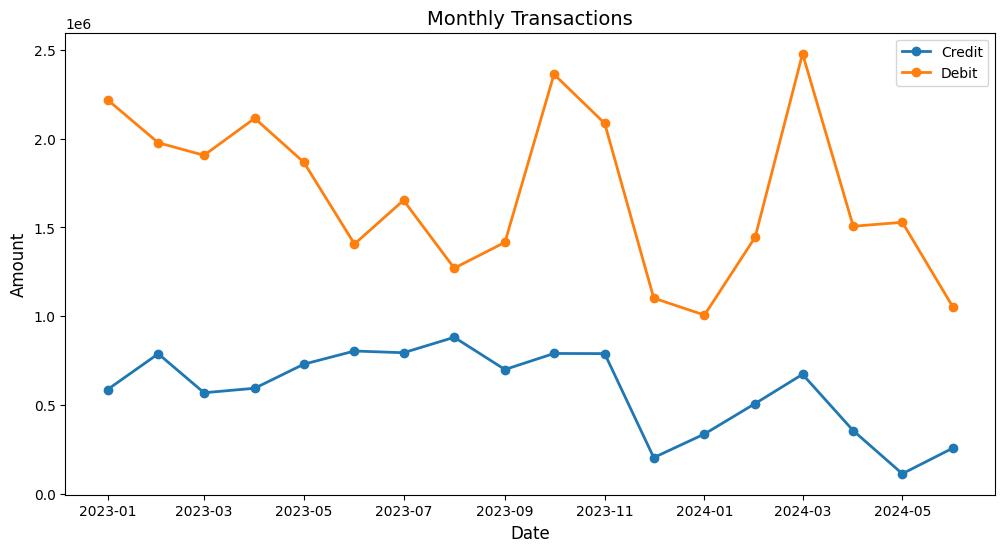

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(transaction_date['Date'], transaction_date['TransactionAmount_credit'], label='Credit', marker='o', linewidth=2)
plt.plot(transaction_date['Date'], transaction_date['TransactionAmount_debit'], label='Debit', marker='o', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Amount')
plt.title('Monthly Net Transactions')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount', fontsize=12)
plt.title('Monthly Transactions', fontsize=14)
plt.legend()
plt.show()

<h4 >
Task 2.3 - Identify top and bottom performing accounts based on net inflow.
</h4>

In [25]:

credits_gb_accid=jp_morgan[jp_morgan['TransactionType']=="deposit"].groupby(by=['AccountID'])["TransactionAmount"].sum().reset_index()


debits_gb_accid=jp_morgan[jp_morgan['TransactionType'].isin(["withdrawal","payment","transfer"])].groupby(by=['AccountID'])["TransactionAmount"].sum().reset_index()


Netflow_ = credits_gb_accid.merge(
    debits_gb_accid,
    on=['AccountID'],
    how='outer',
    suffixes=('_credit', '_debit')
)
Netflow_=Netflow_.fillna(0)
Netflow_["Netflow"]=Netflow_["TransactionAmount_credit"]-Netflow_["TransactionAmount_debit"]

top_performing_customer=Netflow_.sort_values("Netflow",ascending=False).head(5)
bottom_performing_customer=Netflow_.sort_values("Netflow",ascending=False).tail(5)


In [26]:
top_performing_customer

,AccountID,TransactionAmount_credit,TransactionAmount_debit,Netflow
109,ACC54589,225122.50,0.00,225122.50
131,ACC67713,196130.57,7058.79,189071.79
141,ACC74631,253027.51,102073.41,150954.10
169,ACC87602,162772.57,11912.00,150860.57
26,ACC22036,291395.48,146230.69,145164.80


In [27]:
bottom_performing_customer

,AccountID,TransactionAmount_credit,TransactionAmount_debit,Netflow
158,ACC81631,70661.59,413192.97,-342531.38
4,ACC11285,0.00,373189.53,-373189.53
103,ACC51593,0.00,414370.12,-414370.12
110,ACC55331,0.00,448188.41,-448188.41
17,ACC18140,0.00,458219.21,-458219.21


<h4 >
Task 2.4 - Identify and flag accounts as dormant or inactive if there is a gap of two months or more 
between consecutive transactions.
</h4>

In [28]:
# first we have to sort the jp_morgan dataset by AccountID then by TransactionDate

In [29]:
jp_morgan=jp_morgan.sort_values(["AccountID","TransactionDate"])

In [30]:
jp_morgan["PreviousDate"]=jp_morgan.groupby("AccountID")["TransactionDate"].shift(1)
jp_morgan["NoTransaction"]=jp_morgan.groupby("AccountID")["AccountID"].transform("count")

In [31]:
# NoTransaction column counts the No. of Transactions done by each account in total and it was created so the accounts with only one transaction are also marked inactive as later shift(1) was used which creates nan for first transaction per account and fillna(0) is necessary so Notransaction column is used to mark account with single transaction 

In [32]:
jp_morgan.head(20)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Transactionyear,Transactionmonth,PreviousDate,NoTransaction
666,17,CUST9525,ACC10117,loan,transfer,Savings Account,Firm C,North,Manager 1,2023-11-25,56317.92,90780.26,0.28,769,137,2023,11,NaT,1
312,140,CUST9843,ACC10996,current,withdrawal,Credit Card,Firm D,East,Manager 4,2023-01-21,59601.06,42962.45,0.48,363,185,2023,1,NaT,4
764,63,CUST4373,ACC10996,credit,deposit,Savings Account,Firm B,South,Manager 1,2023-07-01,81608.80,67810.12,0.51,694,103,2023,7,2023-01-21,4
113,106,CUST1547,ACC10996,credit,deposit,Personal Loan,Firm C,North,Manager 4,2023-10-19,92323.66,39827.55,0.67,768,198,2023,10,2023-07-01,4
141,44,CUST3725,ACC10996,credit,transfer,Savings Account,Firm D,South,Manager 4,2023-11-06,-9775.98,105586.15,0.18,383,172,2023,11,2023-10-19,4
716,96,CUST7098,ACC11062,savings,deposit,Personal Loan,Firm E,Central,Manager 3,2023-05-11,61603.77,76772.88,0.92,376,29,2023,5,NaT,4
401,196,CUST3778,ACC11062,credit,transfer,Home Loan,Firm E,North,Manager 4,2023-08-22,103375.34,51672.12,0.81,341,32,2023,8,2023-05-11,4
354,15,CUST4669,ACC11062,loan,withdrawal,Mutual Fund,Firm E,West,Manager 1,2023-12-25,35748.04,105604.12,0.14,304,16,2023,12,2023-08-22,4
124,45,CUST6319,ACC11062,current,payment,Home Loan,Firm E,North,Manager 1,2024-01-08,65201.42,17087.28,0.25,340,222,2024,1,2023-12-25,4
233,88,CUST9439,ACC11188,current,withdrawal,Personal Loan,Firm D,North,Manager 2,2023-03-07,15907.06,44198.84,0.64,388,174,2023,3,NaT,3


In [33]:
# if we are only considering months of each transaction we can get false true if there are two transaction by customer in same month but in diffrent year so i will consider year as a criteria during flagging

# as instructed i created new column for flag in dataset 


In [34]:

jp_morgan['MonthGap'] = (
    (jp_morgan['TransactionDate'].dt.year - jp_morgan['PreviousDate'].dt.year) * 12 +
    (jp_morgan['TransactionDate'].dt.month - jp_morgan['PreviousDate'].dt.month)
)

jp_morgan["MonthGap"]=jp_morgan["MonthGap"].fillna(0)


jp_morgan['DormantFlag'] = np.where(
    (jp_morgan['MonthGap'] >= 2) | (jp_morgan["NoTransaction"] == 1 ),
    'Inactive',
    'Active'
)

<hr>

<h2 style="font-family: 'Courier New';">
Task 3
</h2>

<h4 >
Task 3.1 - Group accounts by activity levels: High, Medium, Low based on transaction frequency on 
your analysis and rubrics
</h4>


- for this task i will use criteria of average time ( in month ) it takes for a account to makes 1 transaction derived from average(MonthGap)
Rubrics :
<ul>
<li>0 - <=1 months is High</li>
<li>1 - <=2 months is Medium</li>
<li>2 - n months is low  </li>
</ul>

In [35]:
activity_level = (
    jp_morgan.groupby(["AccountID","MonthGap"])["DormantFlag"]
    .apply(lambda x: (x == "Inactive").any())
    .reset_index(name="IsInactive")
)

In [36]:
#as IsInactive flag show us true for inactive we will negation it will show fals for IsActive which we did using lambda

activity_level = (
    activity_level
    .groupby('AccountID')
    .agg(
        Avg_MonthGap=('MonthGap', 'mean'),
        IsActive=('IsInactive', lambda x: ~x.any())
    )
    .reset_index()
)

activity_level["ActivityLevel"]=pd.cut(activity_level["Avg_MonthGap"],[-1,1,2,float('inf')],labels=["High","Medium","Low"])


In [37]:
activity_level

,AccountID,Avg_MonthGap,IsActive,ActivityLevel
0,ACC10117,0.00,False,High
1,ACC10996,2.50,False,Low
2,ACC11062,2.00,False,Medium
3,ACC11188,4.00,False,Low
4,ACC11285,1.50,False,Medium
...,...,...,...,...
189,ACC97225,4.33,False,Low
190,ACC97411,3.00,False,Low
191,ACC99117,2.00,False,Medium
192,ACC99409,1.00,False,High


<h4 >
Task 3.2 - Segment customers by average balance and transaction volume.
</h4>

In [38]:
# i have used pd.qcut here in order to create automatic bins for both average account balance and transaction volume as combining them and still making a meaningfull segemntations is hard 

In [39]:
customer_segamentation=jp_morgan.groupby("AccountID").agg( Average_balance=("AccountBalance","mean"),
                                                           Average_Transaction=("TransactionAmount","mean")
                                                         ).reset_index()

In [40]:
customer_segamentation["Balance_Segemntation"]=pd.qcut(customer_segamentation['Average_balance'],
                                              q=5,
                                              labels=["very Low Balance","Low Balance","medium Balance",
                                                      "High Balance","very high Balance"])

customer_segamentation["Transaction_Segemntation"]=pd.qcut(customer_segamentation['Average_Transaction'],
                                              q=5,
                                              labels=["very Low Transaction","Low Transaction",
                                                      "medium Transaction","High Transaction","very high Transaaction"])

In [41]:
customer_segamentation

,AccountID,Average_balance,Average_Transaction,Balance_Segemntation,Transaction_Segemntation
0,ACC10117,90780.26,56317.92,very high Balance,High Transaction
1,ACC10996,64046.57,55939.38,Low Balance,High Transaction
2,ACC11062,62784.10,66482.15,Low Balance,very high Transaaction
3,ACC11188,80558.93,38852.65,High Balance,very Low Transaction
4,ACC11285,95745.55,62198.25,very high Balance,High Transaction
...,...,...,...,...,...
189,ACC97225,80994.27,30005.91,High Balance,very Low Transaction
190,ACC97411,61783.63,51804.44,Low Balance,medium Transaction
191,ACC99117,80478.45,64424.16,High Balance,very high Transaaction
192,ACC99409,32962.94,84524.40,very Low Balance,very high Transaaction


<h4 >
Task 3.3 - Create profiles for :-
<ul>
<li>High-net inflow accounts </li>
<li> High-frequency low-balance accounts </li>
<li>Accounts with negative or near-zero balances</li>
</ul>
</h4>

<h5 >
Task 3.3.1 - Create profiles for :- High-net inflow accounts 
</h5>

Rubric :
- Less then 25,000 = low-net inflow 
- more then 25,000 high-net inflow ( we can also add a medium inflow but were only asked for high so i divided it in low and high )

In [42]:
profile_flag=pd.DataFrame()
profile_flag['AccountID']=Netflow_['AccountID']
profile_flag['High_net_inflow']=np.where(Netflow_['Netflow']>25000,
                                         "High-net Inflow",
                                         "Low-net Inflow"
                                        )

In [43]:
profile_flag

,AccountID,High_net_inflow
0,ACC10117,Low-net Inflow
1,ACC10996,High-net Inflow
2,ACC11062,Low-net Inflow
3,ACC11188,Low-net Inflow
4,ACC11285,Low-net Inflow
...,...,...
189,ACC97225,Low-net Inflow
190,ACC97411,Low-net Inflow
191,ACC99117,Low-net Inflow
192,ACC99409,Low-net Inflow


<h5 >
Task 3.3.2 - Create profiles for :- High-frequency low-balance accounts
</h5>

Rubric:
- if total no of transaction > 3 for account its a high freqency account
- if last balance after transactions is < 2000 for account its a low balance account

In [44]:
Last_Account_b=(jp_morgan.sort_values(by=["TransactionDate"],ascending=True).groupby("AccountID")["AccountBalance"].last().reset_index()) 
#as one account may have multiple balance we take the account balance from last transaction
Transaction_count=(jp_morgan.groupby("AccountID")["TransactionID"].count().reset_index())
Transaction_count.rename(columns={"TransactionID":"Transaction_Freq"},inplace=True)

In [45]:

profile_flag=profile_flag.merge(Transaction_count, on="AccountID",how="left")
profile_flag=profile_flag.merge(Last_Account_b, on="AccountID",how="left")


In [46]:
profile_flag["HighFreq_LowBalance"]=np.where((profile_flag["Transaction_Freq"]>3 ) & (profile_flag["AccountBalance"]<2000),
                                             "High_freq_low_b","non_High_f_Low_b")

<h5 >
Task 3.3.3 - Accounts with negative or near-zero balances
</h5>

In [47]:
profile_flag["zero_nearzero"]=np.where(profile_flag["AccountBalance"]<100,
                                       "near_zero_balance",
                                       "normal_balance")

<hr>

<h2 style="font-family: 'Courier New';">
Task 4
</h2>

<h4 >
Task 4.1 - Track accounts with frequent large withdrawals or overdrafts. 
</h4>

Rubric :
- if TransactionAmount is > 80000 (close to average of withdrawl 83k) it is considered large Withdrawal
- if AccountBalance < 0 it is considered as Overdraft

In [48]:
high_risk=pd.DataFrame()

In [49]:
high_risk = jp_morgan[
    ((jp_morgan["TransactionType"] == "withdrawal") & (jp_morgan["TransactionAmount"] > 80000)) |
    (jp_morgan["AccountBalance"] < 0) 
]

In [50]:
high_risk

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,AccountBalance,RiskScore,CreditRating,TenureMonths,Transactionyear,Transactionmonth,PreviousDate,NoTransaction,MonthGap,DormantFlag
654,76,CUST7887,ACC11285,loan,withdrawal,Savings Account,Firm B,North,Manager 4,2024-06-08,...,77599.99,-0.33,558,17,2024,6,2024-05-24,6,1.00,Active
537,185,CUST4763,ACC15925,loan,withdrawal,Mutual Fund,Firm C,South,Manager 3,2023-09-24,...,146131.43,0.46,411,168,2023,9,2023-02-12,7,7.00,Inactive
639,170,CUST2457,ACC18140,loan,withdrawal,Credit Card,Firm D,East,Manager 2,2023-03-08,...,48687.57,-0.05,733,128,2023,3,NaT,7,0.00,Active
283,36,CUST2109,ACC22255,credit,withdrawal,Credit Card,Firm C,North,Manager 2,2023-09-28,...,46134.39,0.48,625,73,2023,9,2023-01-09,2,8.00,Inactive
759,176,CUST9439,ACC23736,current,withdrawal,Mutual Fund,Firm B,East,Manager 1,2023-07-26,...,113904.96,0.66,323,180,2023,7,2023-01-06,3,6.00,Inactive
649,16,CUST4241,ACC26026,credit,withdrawal,Credit Card,Firm C,Central,Manager 2,2023-04-26,...,39441.56,-0.07,349,177,2023,4,NaT,4,0.00,Active
76,27,CUST5912,ACC28612,credit,withdrawal,Credit Card,Firm C,West,Manager 3,2023-04-30,...,62674.47,0.38,703,136,2023,4,2023-02-04,3,2.00,Inactive
8,83,CUST5574,ACC29007,current,withdrawal,Savings Account,Firm A,East,Manager 1,2024-05-24,...,77522.67,0.62,645,184,2024,5,2024-02-13,4,3.00,Inactive
414,191,CUST1749,ACC29477,current,withdrawal,Credit Card,Firm A,North,Manager 2,2023-07-26,...,50193.67,0.17,813,209,2023,7,2023-03-18,9,4.00,Inactive
568,2,CUST7395,ACC30852,current,transfer,Personal Loan,Firm D,East,Manager 4,2023-12-09,...,-13018.40,0.28,320,8,2023,12,2023-08-04,7,4.00,Inactive


<h4 >
Task 4.2 - Calculate balance volatility using standard deviation or coefficient of variation.  
</h4>

In [51]:

volatility=jp_morgan.groupby(by="AccountID").agg(
                                    Balance_avg=("AccountBalance", "mean"),
                                    Balance_std=("AccountBalance", "std")).reset_index()

volatility["CV"]=volatility["Balance_std"]/volatility["Balance_avg"]


In [52]:
volatility

,AccountID,Balance_avg,Balance_std,CV
0,ACC10117,90780.26,NaN,NaN
1,ACC10996,64046.57,30390.80,0.47
2,ACC11062,62784.10,37598.38,0.60
3,ACC11188,80558.93,33781.83,0.42
4,ACC11285,95745.55,42139.17,0.44
...,...,...,...,...
189,ACC97225,80994.27,33590.60,0.41
190,ACC97411,61783.63,34715.82,0.56
191,ACC99117,80478.45,28817.57,0.36
192,ACC99409,32962.94,30169.33,0.92


<h4 >
Task 4.3 - Use IQR or z-score methods to detect anomalies. 
</h4>

- i will use IQR score to detect anomalies
  
Rubric
- if Transaction Amount is < then lower Or more then upper ,it is considered anomaly/outliers

In [53]:

Q1 =jp_morgan["TransactionAmount"].quantile(0.25)
Q3 =jp_morgan["TransactionAmount"].quantile(0.75)

IQR =Q3 - Q1

lower =Q1 - 1.5 * IQR
upper =Q3 + 1.5 * IQR

jp_morgan["Anomaly"] =(
    (jp_morgan["TransactionAmount"] < lower) |
    (jp_morgan["TransactionAmount"] > upper)
)


<h4 >
Task 4.4 - Highlight customers with irregular or suspicious transaction behavior. 
</h4>

in order to detect irregular or suspecious Customer we will use :

- Overdraft Account balance
- Larger transfer Amount
- CV



Rubric
- If balance is less then 0
or
- if Withdrawal TransactionAmount > 80,000
or
- If Coefficient of variance > 0.5
  
then a customer is considered Suspicious/Irregular

In [54]:
Suspecious_Customer=pd.DataFrame()

In [55]:

Suspecious_Customer=jp_morgan[["CustomerID","AccountID","TransactionType","TransactionAmount","AccountBalance"]].copy()
Suspecious_Customer["irregular_trans"]=(
    ((Suspecious_Customer["TransactionType"] == "withdrawal") & (Suspecious_Customer["TransactionAmount"] > 80000)) |
    (Suspecious_Customer["AccountBalance"] < 0) )

Suspecious_Customer=Suspecious_Customer.groupby(by=["CustomerID"]).agg(
                                                        Irregular_tran=("irregular_trans","any"),
                                                        Balance_avg=("TransactionAmount","mean"),
                                                        Balance_std=("TransactionAmount","std"))

Suspecious_Customer["Irregular_CV"]=np.where(Suspecious_Customer["Balance_std"]/Suspecious_Customer["Balance_avg"]>0.5,
                                             True,False)
Suspecious_Customer["Suspeciou_customer"]=(Suspecious_Customer["Irregular_tran"] | Suspecious_Customer["Irregular_CV"])


<hr>

<h2 style="font-family: 'Courier New';">
Task 5 - extensive exploratory data analysis with attractive visualizations
</h2>

- Transaction Count by Transaction Type (Pie Chart)

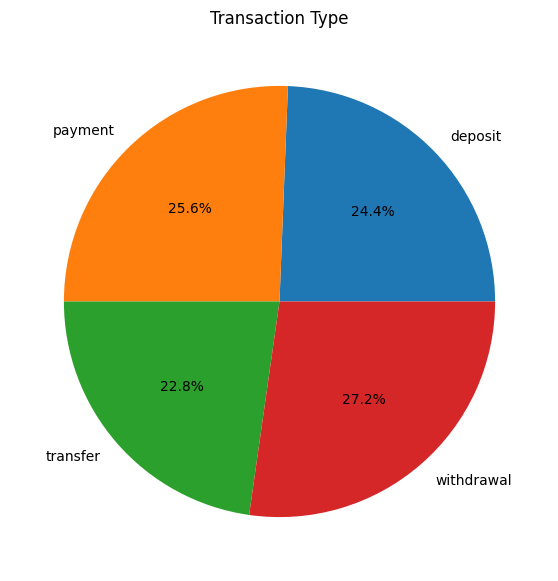

In [56]:
transaction_type = (
    jp_morgan.groupby("TransactionType")["TransactionID"].count().reset_index(name="Transaction_Count")
)

plt.figure(figsize=(7,7))
plt.pie(transaction_type["Transaction_Count"],labels=transaction_type["TransactionType"],autopct='%1.1f%%')

plt.title("Transaction Type")
plt.show()

- No of Transactions by Account Type (Bar chart)

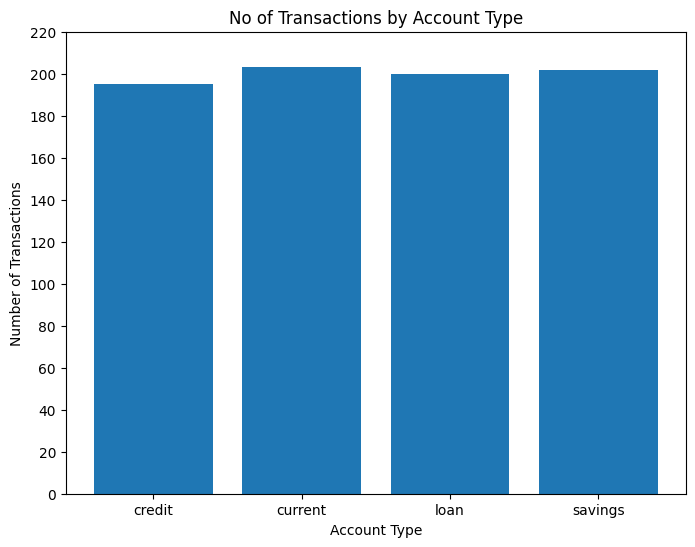

In [57]:
account_type = (
    jp_morgan.groupby("AccountType")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(8,6))
plt.bar(
    account_type["AccountType"],
    account_type["Transaction_Count"]
)

plt.title("No of Transactions by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Number of Transactions")
max_val = account_type["Transaction_Count"].max()
plt.yticks(np.arange(0, max_val + 20, 20))
plt.show()

- Count of Product Type (Pie chart)

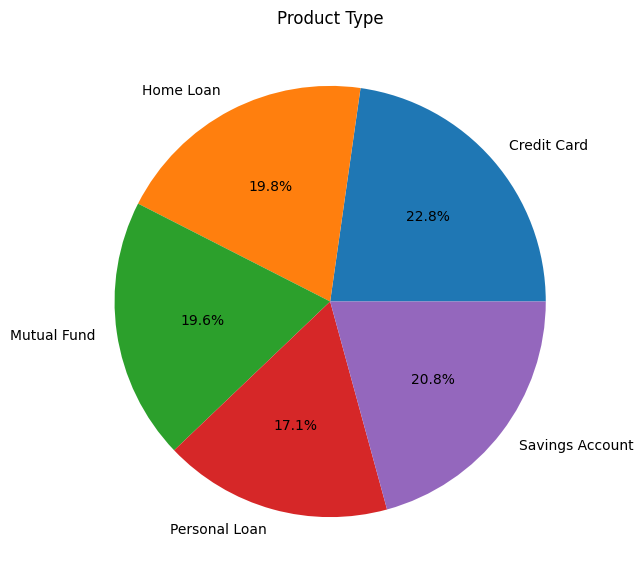

In [58]:
product_type = (
    jp_morgan.groupby("Product")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(7,7))
plt.pie(
    product_type["Transaction_Count"],
    labels=product_type["Product"],
    autopct='%1.1f%%'
)

plt.title("Product Type")
plt.show()

- No of Transactions by Transaction Type (Bar chart)

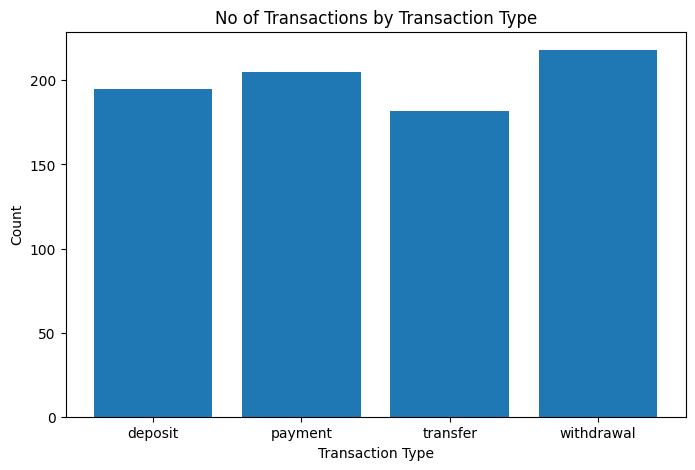

In [59]:
trans_count = (
    jp_morgan.groupby("TransactionType")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(8,5))
plt.bar(
    trans_count["TransactionType"],
    trans_count["Transaction_Count"]
)

plt.title("No of Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

- Number of Transactions by Region (Line chart)

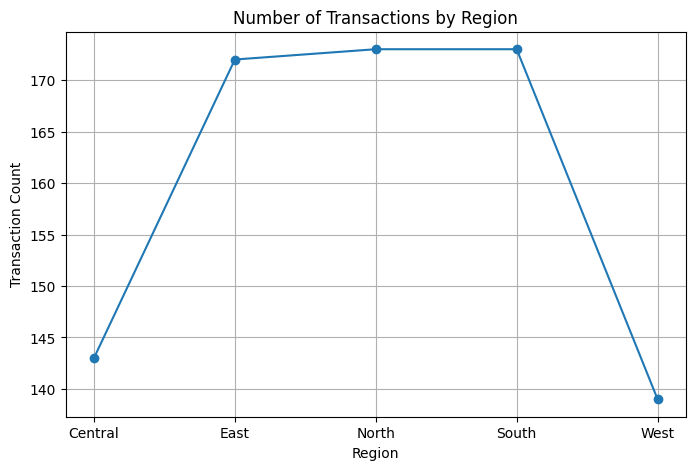

In [60]:
region_count = (
    jp_morgan.groupby("Region")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(8,5))

plt.plot(
    region_count["Region"],
    region_count["Transaction_Count"],
    marker='o'
)

plt.title("Number of Transactions by Region")
plt.xlabel("Region")
plt.ylabel("Transaction Count")
plt.grid(True)
plt.show()

- Number of Transactions by Relationship Manager (Area chart)

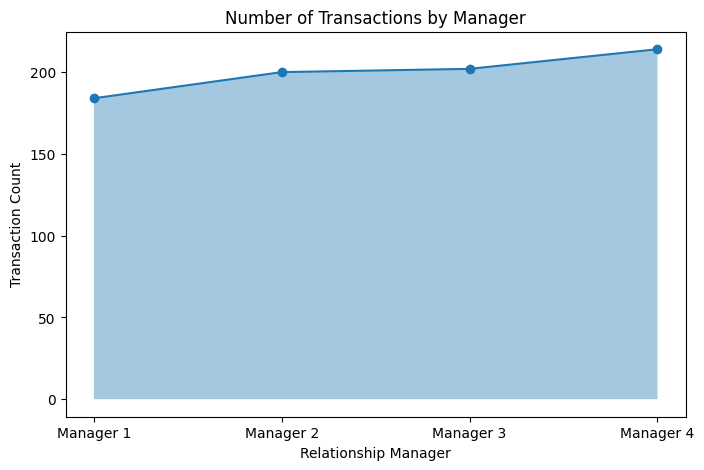

In [61]:
manager_count = (
    jp_morgan.groupby("Manager")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(8,5))

plt.fill_between(
    manager_count["Manager"],
    manager_count["Transaction_Count"],
    alpha=0.4
)

plt.plot(
    manager_count["Manager"],
    manager_count["Transaction_Count"],
    marker='o'
)

plt.title("Number of Transactions by Manager")
plt.xlabel("Relationship Manager")
plt.ylabel("Transaction Count")
plt.show()

- Average Transaction Amount by Relationship Manager (Line Chart)

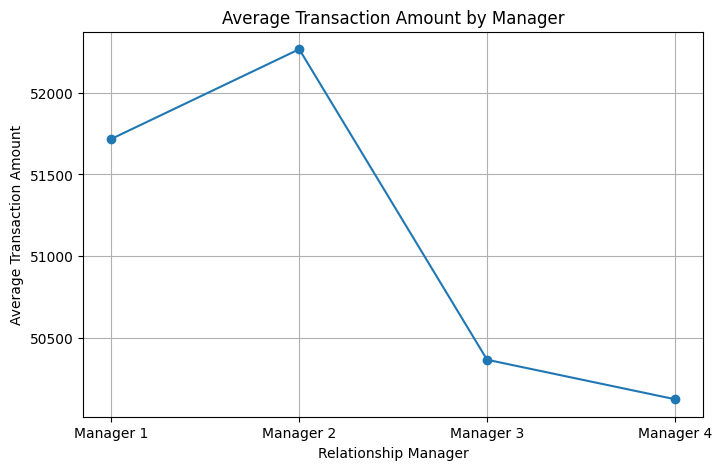

In [62]:
avg_manager = (
    jp_morgan.groupby("Manager")["TransactionAmount"]
    .mean()
    .reset_index(name="Average_Amount")
)

plt.figure(figsize=(8,5))

plt.plot(
    avg_manager["Manager"],
    avg_manager["Average_Amount"],
    marker='o'
)

plt.title("Average Transaction Amount by Manager")
plt.xlabel("Relationship Manager")
plt.ylabel("Average Transaction Amount")
plt.grid(True)
plt.show()

- Average Amount vs Number of Transactions by Transaction Type (Combo Chart)

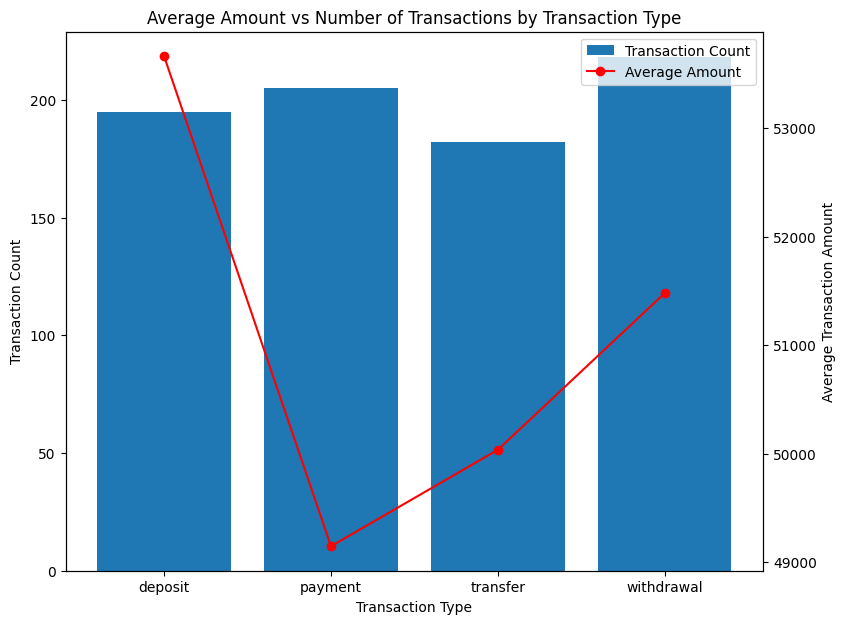

In [63]:
avg_vs_count = (
    jp_morgan.groupby("TransactionType")
    .agg(
        Average_Amount=("TransactionAmount", "mean"),
        Transaction_Count=("TransactionID", "count")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(9,7))

bar = ax1.bar(
    avg_vs_count["TransactionType"],
    avg_vs_count["Transaction_Count"],
    label="Transaction Count"        # Add label
)
ax1.set_xlabel("Transaction Type")
ax1.set_ylabel("Transaction Count")

ax2 = ax1.twinx()

line = ax2.plot(
    avg_vs_count["TransactionType"],
    avg_vs_count["Average_Amount"],
    marker='o', color="red",
    label="Average Amount"           # Add label
)
ax2.set_ylabel("Average Transaction Amount")

# Combine handles from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.title("Average Amount vs Number of Transactions by Transaction Type")
plt.show()

- Total Transaction Amount by Account Type (Bar chart)

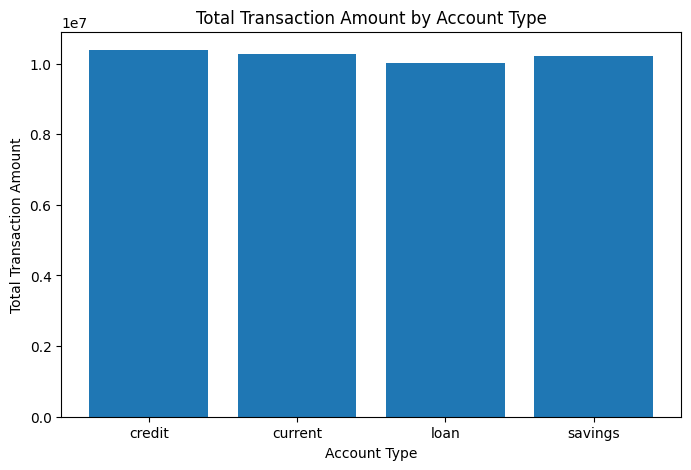

In [64]:
sum_account = (
    jp_morgan.groupby("AccountType")["TransactionAmount"]
    .sum()
    .reset_index(name="Total_Amount")
)

plt.figure(figsize=(8,5))

plt.bar(
    sum_account["AccountType"],
    sum_account["Total_Amount"]
)

plt.title("Total Transaction Amount by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Total Transaction Amount")
plt.show()

- Average Transaction Amount by Region (Bar chart)

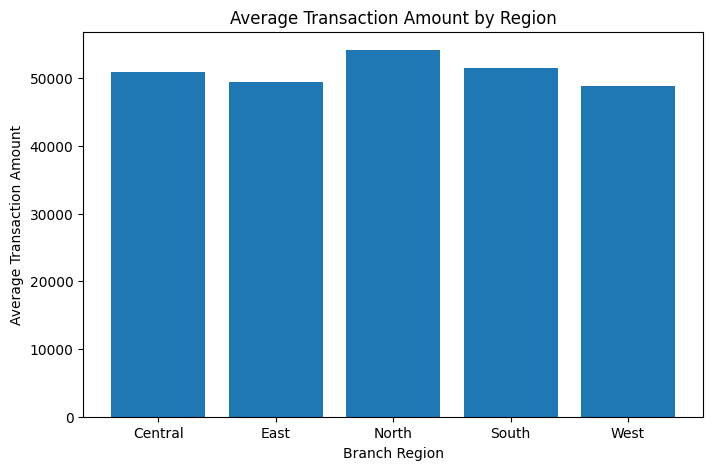

In [65]:
avg_region = (
    jp_morgan.groupby("Region")["TransactionAmount"]
    .mean()
    .reset_index(name="Average_Amount")
)

plt.figure(figsize=(8,5))

plt.bar(
    avg_region["Region"],
    avg_region["Average_Amount"]
)

plt.title("Average Transaction Amount by Region")
plt.xlabel("Branch Region")
plt.ylabel("Average Transaction Amount")
plt.show()

- Average Amount vs Count of Transactions by Account Type (Combo Chart)

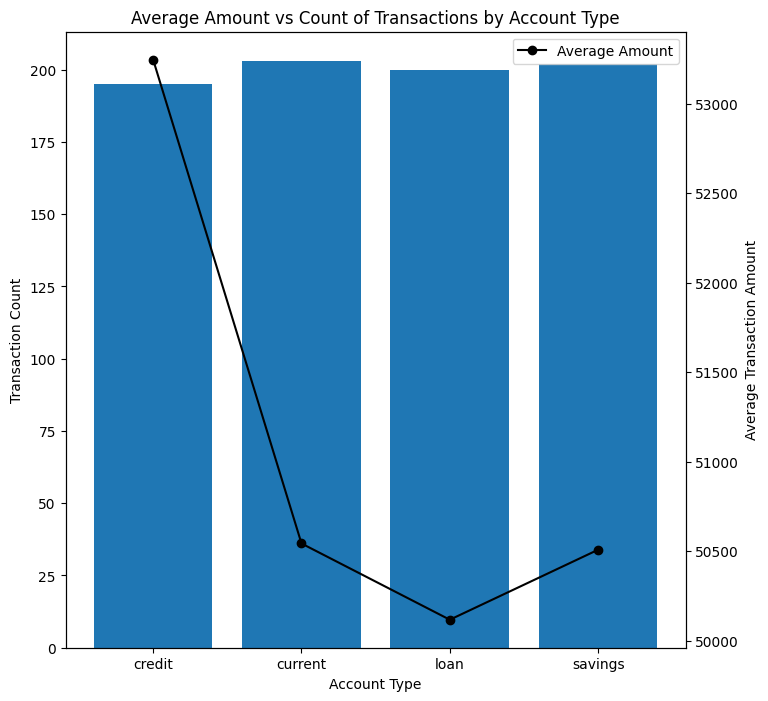

In [66]:
acc_summary = (
    jp_morgan.groupby("AccountType")
    .agg(
        Average_Amount=("TransactionAmount", "mean"),
        Transaction_Count=("TransactionID", "count")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8,8))

ax1.bar(
    acc_summary["AccountType"],
    acc_summary["Transaction_Count"]
    ,label="Transaction count"
)

ax1.set_xlabel("Account Type")
ax1.set_ylabel("Transaction Count")

ax2 = ax1.twinx()

ax2.plot(
    acc_summary["AccountType"],
    acc_summary["Average_Amount"],
    marker='o',color="black",
    label="Average Amount"
)

ax2.set_ylabel("Average Transaction Amount")
plt.legend()
plt.title("Average Amount vs Count of Transactions by Account Type")
plt.show()

- Average Transaction Amount by Region and Transaction Type

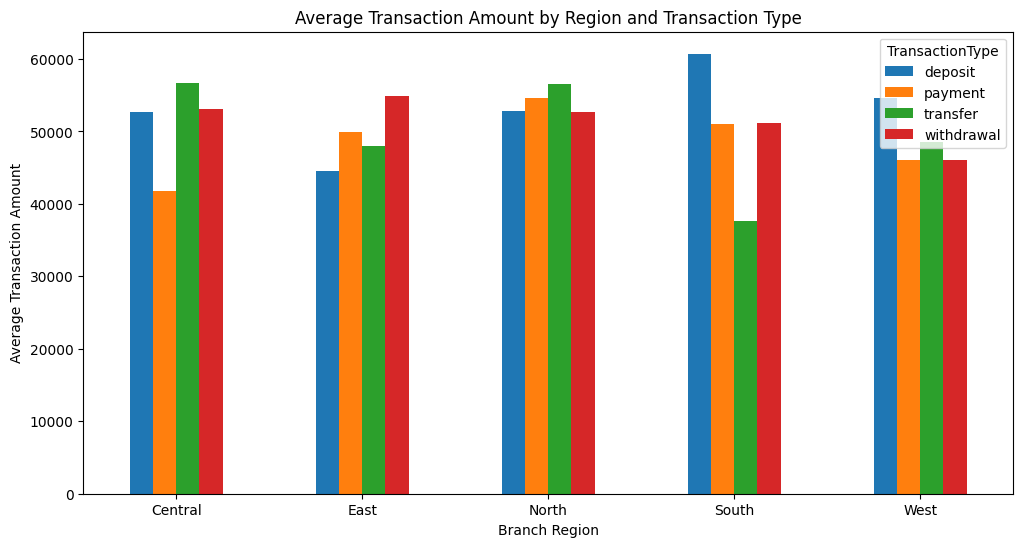

In [67]:
region_trans = (
    jp_morgan.groupby(["Region", "TransactionType"])["TransactionAmount"]
    .mean()
    .reset_index(name="Average_Transaction_Amount")
)

pivot_region = region_trans.pivot(
    index="Region",
    columns="TransactionType",
    values="Average_Transaction_Amount"
)

pivot_region.plot(kind="bar", figsize=(12,6))

plt.title("Average Transaction Amount by Region and Transaction Type")
plt.xlabel("Branch Region")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.show()

- Average Transaction Amount by Transaction Type (Line Chart)

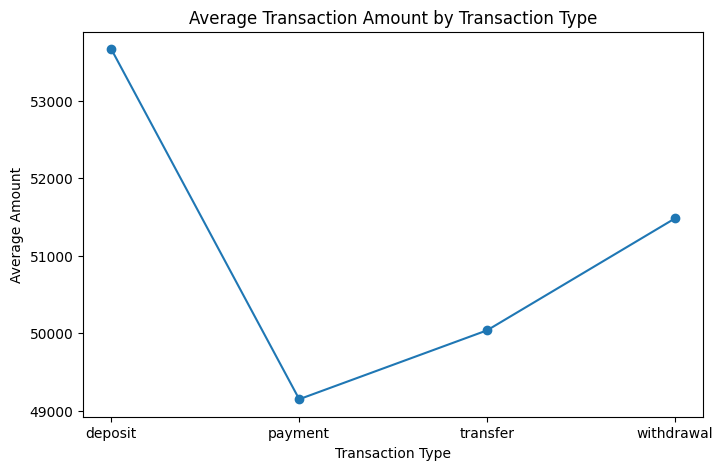

In [68]:
avg_trans_type = (
    jp_morgan.groupby("TransactionType")["TransactionAmount"]
    .mean()
    .reset_index(name="Average_Amount")
)

plt.figure(figsize=(8,5))
plt.plot(
    avg_trans_type["TransactionType"],
    avg_trans_type["Average_Amount"],
    marker='o'
)

plt.title("Average Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")
plt.show()

- Average Amount by Product Type (Bar Chart)

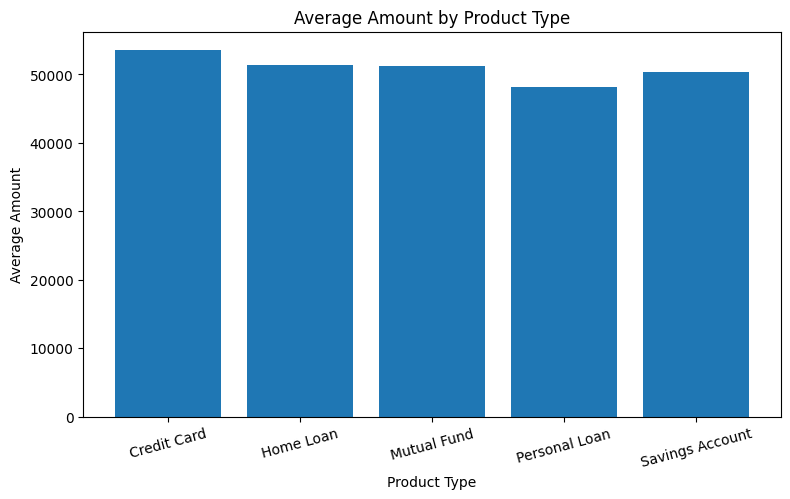

In [69]:
avg_product = (
    jp_morgan.groupby("Product")["TransactionAmount"]
    .mean()
    .reset_index(name="Average_Amount")
)

plt.figure(figsize=(9,5))
plt.bar(
    avg_product["Product"],
    avg_product["Average_Amount"]
)

plt.title("Average Amount by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=15)
plt.show()

- Average Risk Score by Transaction Type

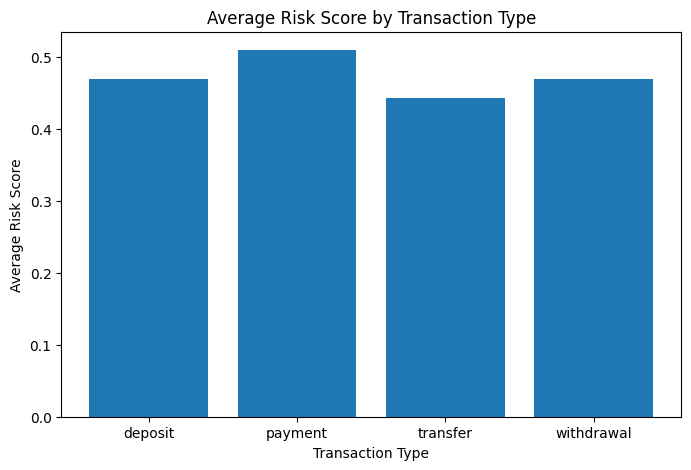

In [70]:
risk_score = (
    jp_morgan.groupby("TransactionType")["RiskScore"]
    .mean()
    .reset_index(name="Average_Risk_Score")
)

plt.figure(figsize=(8,5))
plt.bar(
    risk_score["TransactionType"],
    risk_score["Average_Risk_Score"]
)

plt.title("Average Risk Score by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Risk Score")
plt.show()

- Biggest Transaction Amount by Transaction Type

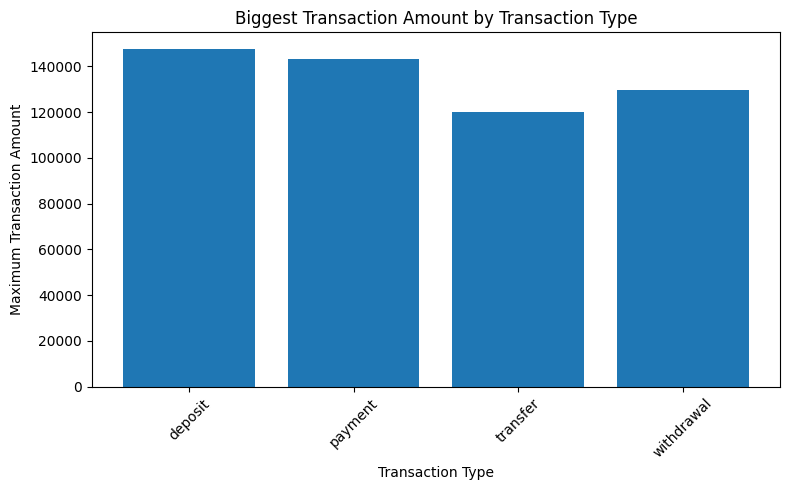

In [71]:
biggest_transaction = (
    jp_morgan.groupby("TransactionType")["TransactionAmount"]
    .max()
    .reset_index(name="Maximum_Transaction")
)

plt.figure(figsize=(8,5))

plt.bar(
    biggest_transaction["TransactionType"],
    biggest_transaction["Maximum_Transaction"]
)

plt.title("Biggest Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Maximum Transaction Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<hr>

<h2 style="font-family: 'Courier New';">
Task 6
</h2>

<h4 >
Task 6.1 Test whether high-volume transaction accounts have statistically higher average 
balances than low-volume accounts. 
</h4>

- due to term volume i will assume that count of transaction is the criteria 
- accounts with > average(Tansaction volumne) will be flaged as 'high_volume' and < average(Transaction volume) will be flagged 'low_volume'

In [72]:

H0 = "High-volume transaction accounts do not have statistically higher average balances than low-volume accounts."

H1 = "High-volume transaction accounts have statistically higher average balances than low-volume accounts."

test_set=jp_morgan.groupby(by="AccountID").agg(
    Transaction_c=("TransactionID","count"),
    Balance_avg=("AccountBalance","mean")).reset_index()

median_count=test_set["Transaction_c"].median()

high_vol=test_set[test_set["Transaction_c"]>median_count]["Balance_avg"]  
low_vol=test_set[test_set["Transaction_c"]<median_count]["Balance_avg"]  

t_val,p_val=ttest_ind(high_vol,low_vol)

print(f"T-value:{t_val:.4f}")
print(f"P-value:{p_val:.4f}")
print(f"High-volume avg balance :{high_vol.mean():,.2f}")  
print(f"Low-volume  avg balance :{low_vol.mean():,.2f}")

if p_val < 0.05 and high_vol.mean() > low_vol.mean():
    print("Result: Reject H0 —", H1)
elif p_val < 0.05 and high_vol.mean() < low_vol.mean():
    print("Result: Reject H0 — Low-volume accounts actually have higher average balances.")
else:
    print("Result: Fail to Reject H0 —", H0)


T-value:-0.1267
P-value:0.8993
High-volume avg balance :74,570.68
Low-volume  avg balance :74,944.96
Result: Fail to Reject H0 — High-volume transaction accounts do not have statistically higher average balances than low-volume accounts.


<h4 >
Task 6.2 Conduct hypothesis testing based on segmentation. 
</h4>

The segementation we will use :-
- High balance account vs Low balance account
- Accounts with High tansfer amount vs Low transfer amount
- Saving accounts vs Current account
- Lone and credit accounts vs current and saving account
- central region vs North and South and East and West

All the testing will be done using P score

In [73]:
# this is a helper function used to display the result

def Hypo_analysis(p_val: float, h0: str, h1: str):
    
    if p_val < 0.05 :
        print(f"The Null Hypothesis was rejected and H1 - {h1} is True ")
        print("P score = ",f"{p_val:.5f}", " Which is Less then 0.05")
    
    else:
        print(f"The Null Hypothesis was accepted H0 - {h0} is true as we were not able to reject it")
        print("P score = ",f"{p_val:.5f}"," Which is greater then or equal to 0.05")

        


- H0 - There is no statistically significant difference in average transaction amount between high-balance and low-balance accounts.

- H1 - There is a statistically significant difference in average transaction amount between high-balance and low-balance accounts.


In [74]:

H0 = "There is no statistically significant difference in average transaction amount between high-balance and low-balance accounts."

H1 = "There is a statistically significant difference in average transaction amount between high-balance and low-balance accounts."

balance_seg=jp_morgan.sort_values(by=["AccountID","TransactionDate"],ascending=True).groupby(by="AccountID").agg(
                                        Balance_last=("AccountBalance","last"),
                                        Transaction_avg=("TransactionAmount","mean"),
                                        Riskscore_avg=("RiskScore","mean")
)

mean_balance=balance_seg["Balance_last"].median()

high_balance_acc=balance_seg[balance_seg["Balance_last"]>mean_balance]["Transaction_avg"]
low_balance_acc=balance_seg[balance_seg["Balance_last"]<mean_balance]["Transaction_avg"]

t_val,p_val=ttest_ind(high_balance_acc,low_balance_acc)
 
Hypo_analysis(p_val,H0,H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average transaction amount between high-balance and low-balance accounts. is true as we were not able to reject it
P score =  0.67686  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average risk score between high-transaction and low-transaction accounts.

- H1 - There is a statistically significant difference in average risk score between high-transaction and low-transaction accounts.


In [75]:

H0 = "There is no statistically significant difference in average risk score between high-transaction and low-transaction accounts."

H1 = "There is a statistically significant difference in average risk score between high-transaction and low-transaction accounts."

mean_transaction=balance_seg["Transaction_avg"].mean()

high_transaction_acc=balance_seg[balance_seg["Transaction_avg"]>mean_transaction]["Riskscore_avg"]
low_transaction_acc=balance_seg[balance_seg["Transaction_avg"]<mean_transaction]["Riskscore_avg"]

t_val,p_val=ttest_ind(high_transaction_acc,low_transaction_acc)

Hypo_analysis(p_val,H0,H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average risk score between high-transaction and low-transaction accounts. is true as we were not able to reject it
P score =  0.40580  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average transaction amount between Savings and Current accounts.

- H1 - There is a statistically significant difference in average transaction amount between Savings and Current accounts.


In [76]:

H0 = "There is no statistically significant difference in average transaction amount between Savings and Current accounts."

H1 = "There is a statistically significant difference in average transaction amount between Savings and Current accounts."

acc_seg_sav=jp_morgan[jp_morgan["AccountType"].isin(["savings"])].groupby(by=["AccountID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))

acc_seg_cur=jp_morgan[jp_morgan["AccountType"].isin(["current"])].groupby(by=["AccountID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))
t_val,p_val=ttest_ind(acc_seg_sav["Transaction_avg"],acc_seg_cur["Transaction_avg"])

Hypo_analysis(p_val,H0,H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average transaction amount between Savings and Current accounts. is true as we were not able to reject it
P score =  0.85366  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average transaction amount between Loan/Credit accounts and Current/Savings accounts.

- H1 - There is a statistically significant difference in average transaction amount between Loan/Credit accounts and Current/Savings accounts.


In [77]:

H0 = "There is no statistically significant difference in average transaction amount between Loan/Credit accounts and Current/Savings accounts."

H1 = "There is a statistically significant difference in average transaction amount between Loan/Credit accounts and Current/Savings accounts."

acc_seg_lc=jp_morgan[jp_morgan["AccountType"].isin(["loan","credit"])].groupby(by=["CustomerID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))

acc_seg_cs=jp_morgan[jp_morgan["AccountType"].isin(["current","savings"])].groupby(by=["CustomerID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))

t_val,p_val=ttest_ind(acc_seg_lc["Transaction_avg"],acc_seg_cs["Transaction_avg"])

Hypo_analysis(p_val,H0,H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average transaction amount between Loan/Credit accounts and Current/Savings accounts. is true as we were not able to reject it
P score =  0.93238  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average risk score between the Central region and the other regions.

- H1 - There is a statistically significant difference in average risk score between the Central region and the other regions.


In [78]:

H0 = "There is no statistically significant difference in average risk score between the Central region and the other regions."

H1 = "There is a statistically significant difference in average risk score between the Central region and the other regions."

acc_seg_c=jp_morgan[jp_morgan["Region"].isin(['Central'])].groupby(by=["CustomerID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))

acc_seg_nesw=jp_morgan[jp_morgan["Region"].isin(['North', 'East', 'South', 'West'])].groupby(by=["CustomerID"]).agg(
                                                    Transaction_avg=("TransactionAmount","mean"),
                                                    Riskscore_avg=("RiskScore","mean"))

t_val,p_val=ttest_ind(acc_seg_c["Riskscore_avg"],acc_seg_nesw["Riskscore_avg"])

Hypo_analysis(p_val,H0,H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average risk score between the Central region and the other regions. is true as we were not able to reject it
P score =  0.48922  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average risk score between long-tenure and short-tenure accounts.

- H1 - There is a statistically significant difference in average risk score between long-tenure and short-tenure accounts.
    

In [79]:

H0 = "There is no statistically significant difference in average risk score between long-tenure and short-tenure accounts."

H1 = "There is a statistically significant difference in average risk score between long-tenure and short-tenure accounts."

tenure_seg=jp_morgan.groupby(by="AccountID").agg(
    Tenure_avg=("TenureMonths","mean"),
    Transaction_avg=("TransactionAmount","mean"),
    Riskscore_avg=("RiskScore","mean")
)

median_tenure=tenure_seg["Tenure_avg"].median()

long_tenure_acc=tenure_seg[
    tenure_seg["Tenure_avg"]>median_tenure
]["Riskscore_avg"]

short_tenure_acc=tenure_seg[
    tenure_seg["Tenure_avg"]<median_tenure
]["Riskscore_avg"]

t_val,p_val=ttest_ind(long_tenure_acc,short_tenure_acc)

print("T-value:",t_val)
print("P-value:",p_val)

Hypo_analysis(p_val,H0,H1)


T-value: -0.25771356448104316
P-value: 0.7969039847805663
The Null Hypothesis was accepted H0 - There is no statistically significant difference in average risk score between long-tenure and short-tenure accounts. is true as we were not able to reject it
P score =  0.79690  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average account balance between high-credit-rating and low-credit-rating customers.
  
- H1 - There is a statistically significant difference in average account balance between high-credit-rating and low-credit-rating customers.
  

In [80]:

H0 = "There is no statistically significant difference in average account balance between high-credit-rating and low-credit-rating customers."

H1 = "There is a statistically significant difference in average account balance between high-credit-rating and low-credit-rating customers."

credit_seg = jp_morgan.groupby(by="CustomerID").agg(
    CreditRating_avg=("CreditRating", "mean"),
    Balance_avg=("AccountBalance", "mean")
)

median_credit = credit_seg["CreditRating_avg"].median()

high_credit_acc = credit_seg[credit_seg["CreditRating_avg"] > median_credit]["Balance_avg"]
low_credit_acc  = credit_seg[credit_seg["CreditRating_avg"] < median_credit]["Balance_avg"]

t_val, p_val = ttest_ind(high_credit_acc, low_credit_acc)

Hypo_analysis(p_val, H0, H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average account balance between high-credit-rating and low-credit-rating customers. is true as we were not able to reject it
P score =  0.65683  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average account balance between high-risk-score and low-risk-score accounts.
    
- H1 - High-risk-score accounts have a statistically significant difference in average account balance compared to low-risk-score accounts.
    

In [81]:

H0 = "There is no statistically significant difference in average account balance between high-risk-score and low-risk-score accounts."

H1 = "High-risk-score accounts have a statistically significant difference in average account balance compared to low-risk-score accounts."

risk_seg = jp_morgan.groupby(by="AccountID").agg(
    RiskScore_avg=("RiskScore", "mean"),
    Balance_avg=("AccountBalance", "mean")
)

median_risk = risk_seg["RiskScore_avg"].median()

high_risk_acc = risk_seg[risk_seg["RiskScore_avg"] > median_risk]["Balance_avg"]
low_risk_acc  = risk_seg[risk_seg["RiskScore_avg"] < median_risk]["Balance_avg"]

t_val, p_val = ttest_ind(high_risk_acc, low_risk_acc)

Hypo_analysis(p_val, H0, H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average account balance between high-risk-score and low-risk-score accounts. is true as we were not able to reject it
P score =  0.56999  Which is greater then or equal to 0.05



- H0 - There is no statistically significant difference in average credit rating between long-tenure and short-tenure customers.
    
- H1 - Long-tenure customers have a statistically significant difference in average credit rating compared to short-tenure customers.
    

In [82]:

H0 = "There is no statistically significant difference in average credit rating between long-tenure and short-tenure customers."

H1 = "Long-tenure customers have a statistically significant difference in average credit rating compared to short-tenure customers."

tenure_credit_seg = jp_morgan.groupby(by="CustomerID").agg(
    Tenure_avg=("TenureMonths", "mean"),
    CreditRating_avg=("CreditRating", "mean")
)

median_tenure = tenure_credit_seg["Tenure_avg"].median()

long_tenure_acc  = tenure_credit_seg[tenure_credit_seg["Tenure_avg"] > median_tenure]["CreditRating_avg"]
short_tenure_acc = tenure_credit_seg[tenure_credit_seg["Tenure_avg"] < median_tenure]["CreditRating_avg"]

t_val, p_val = ttest_ind(long_tenure_acc, short_tenure_acc)

Hypo_analysis(p_val, H0, H1)


The Null Hypothesis was accepted H0 - There is no statistically significant difference in average credit rating between long-tenure and short-tenure customers. is true as we were not able to reject it
P score =  0.39819  Which is greater then or equal to 0.05


# Appendix — Variable Reference

All variables defined across Tasks 1–6 

---


## Task 2 — Descriptive Transactional Analysis

- `credits` — *(DataFrame)* Monthly total of deposit (credit) transaction amounts, grouped by Transactionyear and Transactionmonth.
- `debits` — *(DataFrame)* Monthly total of debit transaction amounts (withdrawal, payment, transfer), grouped by year and month.
- `transaction` — *(DataFrame)* Merged monthly summary of credits and debits with a calculated Net column (credits minus debits). Core table for Task 2 summaries and trend plot.
- `transaction_date` — *(DataFrame)* Copy of transaction with a formatted Date column (YYYY-MM string) used as the x-axis for the credits vs debits trend line plot.
- `credits_gb_accid` — *(DataFrame)* Total deposit amount per AccountID across all time. Used to build the net inflow ranking.
- `debits_gb_accid` — *(DataFrame)* Total debit amount per AccountID across all time. Used to build the net inflow ranking.
- `Netflow_` — *(DataFrame)* Per-account net inflow (total deposits minus total debits). Null values filled with 0. Used to rank top and bottom performing accounts.
- `top_performing_customer` — *(DataFrame)* Top 5 accounts by highest net inflow from Netflow_.
- `bottom_performing_customer` — *(DataFrame)* Bottom 5 accounts by lowest net inflow from Netflow_.
- `Transaction_count` — *(DataFrame)* Count of transactions per AccountID. Merged into profile_flag in Task 3.

---

## Task 3 — Customer Profile Building

- `activity_level` — *(DataFrame)* Per-account activity classification. Computes average MonthGap between consecutive transactions and assigns High / Medium / Low activity label using pd.cut bins.
- `customer_segamentation` — *(DataFrame)* Per-account segmentation by average balance (Balance_Segmentation) and transaction volume (Volume_Segmentation), both created using pd.qcut into 5 quantile bins.
- `profile_flag` — *(DataFrame)* Master profile table per AccountID. Contains flag columns: HighNetInflow, HighFreq_LowBalance, and zero_nearzero. Built by merging Netflow_, Transaction_count, and Last_Account_b.
- `Last_Account_b` — *(DataFrame)* Last recorded AccountBalance per AccountID taken from the most recent transaction by date. Used in profile_flag to check current balance status.

---

## Task 4 — Financial Risk Identification

- `high_risk` — *(DataFrame)* Accounts flagged as high risk: those with large withdrawal transactions (>80,000) OR with a negative AccountBalance (overdraft).
- `volatility` — *(DataFrame)* Per-account balance volatility metrics: Balance_avg (mean of AccountBalance), Balance_std (std of AccountBalance), and CV (coefficient of variation = std / mean). Higher CV means more volatile account.
- `Q1` — *(Float)* 25th percentile of TransactionAmount. Used in IQR anomaly detection.
- `Q3` — *(Float)* 75th percentile of TransactionAmount. Used in IQR anomaly detection.
- `IQR` — *(Float)* Interquartile range: Q3 minus Q1. Measures the spread of the middle 50% of transaction amounts.
- `lower` — *(Float)* Lower IQR anomaly boundary: Q1 - 1.5 × IQR. Transactions below this are flagged as outliers.
- `upper` — *(Float)* Upper IQR anomaly boundary: Q3 + 1.5 × IQR. Transactions above this are flagged as outliers.
- `Suspecious_Customer` — *(DataFrame)* Per-customer summary of suspicious activity. Contains withdrawal count, overdraft count, anomaly count (IQR), and a composite Suspeciou_customer flag.

---

## Task 5 — Visualisation

- `transaction_type` — *(DataFrame)* Transaction count and total amount grouped by TransactionType. Used in bar/pie charts comparing deposit, withdrawal, payment, transfer volumes.
- `account_type` — *(DataFrame)* Transaction count and total amount grouped by AccountType (savings, current, loan, credit).
- `max_val` — *(Float)* Maximum Transaction_Count from account_type. Used to set y-axis scale on the account type bar chart.
- `product_type` — *(DataFrame)* Transaction count and total amount grouped by Product (Credit Card, Home Loan, Mutual Fund, etc.).
- `trans_count` — *(DataFrame)* Transaction count per TransactionType. Used for a count-focused bar chart.
- `region_count` — *(DataFrame)* Transaction count grouped by Region (North, South, East, West, Central).
- `manager_count` — *(DataFrame)* Transaction count grouped by Manager. Used in the Manager area chart.
- `avg_manager` — *(DataFrame)* Average transaction amount per Manager.
- `avg_vs_count` — *(DataFrame)* Average transaction amount and transaction count per TransactionType. Used in the first combo (twinx) chart.
- `sum_account` — *(DataFrame)* Total transaction amount per AccountType.
- `avg_region` — *(DataFrame)* Average transaction amount per Region.
- `acc_summary` — *(DataFrame)* Per-AccountType summary of transaction count and average amount. Used in the second combo (twinx) chart.
- `region_trans` — *(DataFrame)* Transaction count grouped by both Region and TransactionType. Source for the pivot heatmap.
- `pivot_region` — *(DataFrame)* Pivoted version of region_trans with Region as index and TransactionType as columns. Input for the region × transaction type heatmap.
- `avg_trans_type` — *(DataFrame)* Average TransactionAmount per TransactionType.
- `avg_product` — *(DataFrame)* Average TransactionAmount per Product.
- `risk_score` — *(DataFrame)* Average RiskScore per TransactionType. Used to visualize which transaction types correlate with higher customer risk.
- `biggest_transaction` — *(DataFrame)* Largest TransactionAmount per TransactionType.

---

## Task 6 — Hypothesis Testing

### Shared

- `H0` — *(String)* Null hypothesis statement. Reassigned before each t-test.
- `H1` — *(String)* Alternative hypothesis statement. Reassigned before each t-test.
- `t_val` — *(Float)* T-statistic from ttest_ind(). Reassigned after each test.
- `p_val` — *(Float)* P-value from ttest_ind(). If <0.05, H0 is rejected. Passed to Hypo_analysis().

### Task 6.1 — High-Volume vs Low-Volume Accounts

- `test_set` — *(DataFrame)* Per-AccountID summary with Transaction_c (count) and Balance_avg (mean AccountBalance).
- `median_count` — *(Float)* Median transaction count across all accounts. Threshold to split high and low volume groups.
- `high_vol` — *(Series)* Balance_avg for accounts with transaction count above median_count.
- `low_vol` — *(Series)* Balance_avg for accounts with transaction count below median_count.

### Task 6.2 — Segmentation Tests

- `balance_seg` — *(DataFrame)* Per-AccountID summary with Balance_last, Transaction_avg, and Riskscore_avg. Shared base for hypotheses 1 and 2.
- `mean_balance` — *(Float)* Median of Balance_last. Threshold for high/low balance split.
- `high_balance_acc` — *(Series)* Transaction_avg for accounts with Balance_last above mean_balance.
- `low_balance_acc` — *(Series)* Transaction_avg for accounts with Balance_last below mean_balance.
- `mean_transaction` — *(Float)* Mean of Transaction_avg across all accounts. Threshold for high/low transaction split.
- `high_transaction_acc` — *(Series)* Riskscore_avg for accounts with Transaction_avg above mean_transaction.
- `low_transaction_acc` — *(Series)* Riskscore_avg for accounts with Transaction_avg below mean_transaction.
- `acc_seg_sav` — *(DataFrame)* Per-AccountID avg transaction amount for Savings accounts only.
- `acc_seg_cur` — *(DataFrame)* Per-AccountID avg transaction amount for Current accounts only.
- `acc_seg_lc` — *(DataFrame)* Per-CustomerID avg transaction amount for Loan and Credit accounts combined.
- `acc_seg_cs` — *(DataFrame)* Per-CustomerID avg transaction amount for Current and Savings accounts combined.
- `acc_seg_c` — *(DataFrame)* Per-CustomerID avg RiskScore for Central region accounts.
- `acc_seg_nesw` — *(DataFrame)* Per-CustomerID avg RiskScore for North, East, South, and West accounts combined.
- `tenure_seg` — *(DataFrame)* Per-AccountID summary with Tenure_avg. Base for hypothesis 6.
- `median_tenure` — *(Float)* Median tenure across all accounts. Reused as threshold in hypotheses 6 and 9.
- `long_tenure_acc` — *(Series)* RiskScore or CreditRating for accounts with tenure above median_tenure. Reused across two tests.
- `short_tenure_acc` — *(Series)* RiskScore  or CreditRating for accounts with tenure below median_tenure. Reused across two tests.
- `credit_seg` — *(DataFrame)* Per-CustomerID summary of CreditRating_avg and Balance_avg. Base for hypothesis 7.
- `median_credit` — *(Float)* Median CreditRating across all customers. Threshold for high/low credit rating split.
- `high_credit_acc` — *(Series)* Balance_avg for customers with CreditRating above median_credit.
- `low_credit_acc` — *(Series)* Balance_avg for customers with CreditRating below median_credit.
- `risk_seg` — *(DataFrame)* Per-AccountID summary of RiskScore_avg and Balance_avg. Base for hypothesis 8.
- `median_risk` — *(Float)* Median RiskScore across all accounts. Threshold for high/low risk split.
- `high_risk_acc` — *(Series)* Balance_avg for accounts with RiskScore above median_risk.
- `low_risk_acc` — *(Series)* Balance_avg for accounts with RiskScore below median_risk.
- `tenure_credit_seg` — *(DataFrame)* Per-CustomerID summary of Tenure_avg and CreditRating_avg. Base for hypothesis 9.